In [ ]:
!pip install roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 54.8 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ypTf5VqSlbrAfUlUz8Pt")
project = rf.workspace("adzkia").project("pathole-detection-3bbzo")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pathole-Detection-1 in yolov8:: 100%|██████████| 1714/1714 [00:00<00:00, 5036.79it/s]


In [ ]:
# FIND DATA.YAML FILE

import os

for root, dirs, files in os.walk("/content"):
  for file in files:
    if file=="data.yaml":
      print(os.path.join(root,file))

/content/Pathole-Detection-1/data.yaml


In [ ]:
# DISPLAY DATA.YAML CONTENT

yaml_path="/content/Pathole-Detection-1/data.yaml"

with open(yaml_path,"r") as f:
  print(f.read())


names:
- '-'
- Pothole Detection - v1 2023-12-05 4-05pm
nc: 2
roboflow:
  license: CC BY 4.0
  project: pathole-detection-3bbzo
  url: https://universe.roboflow.com/adzkia/pathole-detection-3bbzo/dataset/1
  version: 1
  workspace: adzkia
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
# FIX DATA.YAML

yaml_content = """
names:
  - Road
  - Pothole

nc: 2

train: ../train/images
val: ../valid/images
test: ../test/images
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml fixed successfully")

data.yaml fixed successfully


In [ ]:
# DISPLAY UPDATED DATA.YAML

yaml_path = "/content/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())


names:
  - Road
  - Pothole

nc: 2

train: ../train/images
val: ../valid/images
test: ../test/images



In [ ]:
import os

train_images = len(os.listdir("/content/Pathole-Detection-1/train/images"))
val_images = len(os.listdir("/content/Pathole-Detection-1/valid/images"))
test_images = len(os.listdir("/content/Pathole-Detection-1/test/images"))

print("Train Images:", train_images)
print("Validation Images:", val_images)
print("Test Images:", test_images)

Train Images: 727
Validation Images: 74
Test Images: 50


In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.1 MB/s eta 0:00:00


In [ ]:
# LOAD PRETRAINED YOLOv8 MODEL

from ultralytics import YOLO

model = YOLO("yolov8s.pt")

print("YOLOv8s Loaded Successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8s Loaded Successfully


In [ ]:
# TRAIN MODEL

results = model.train(
    data="/content/Pathole-Detection-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="Pothole_Detection_Project",
    name="Pothole_Model"
)

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pathole-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Pothole_Model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

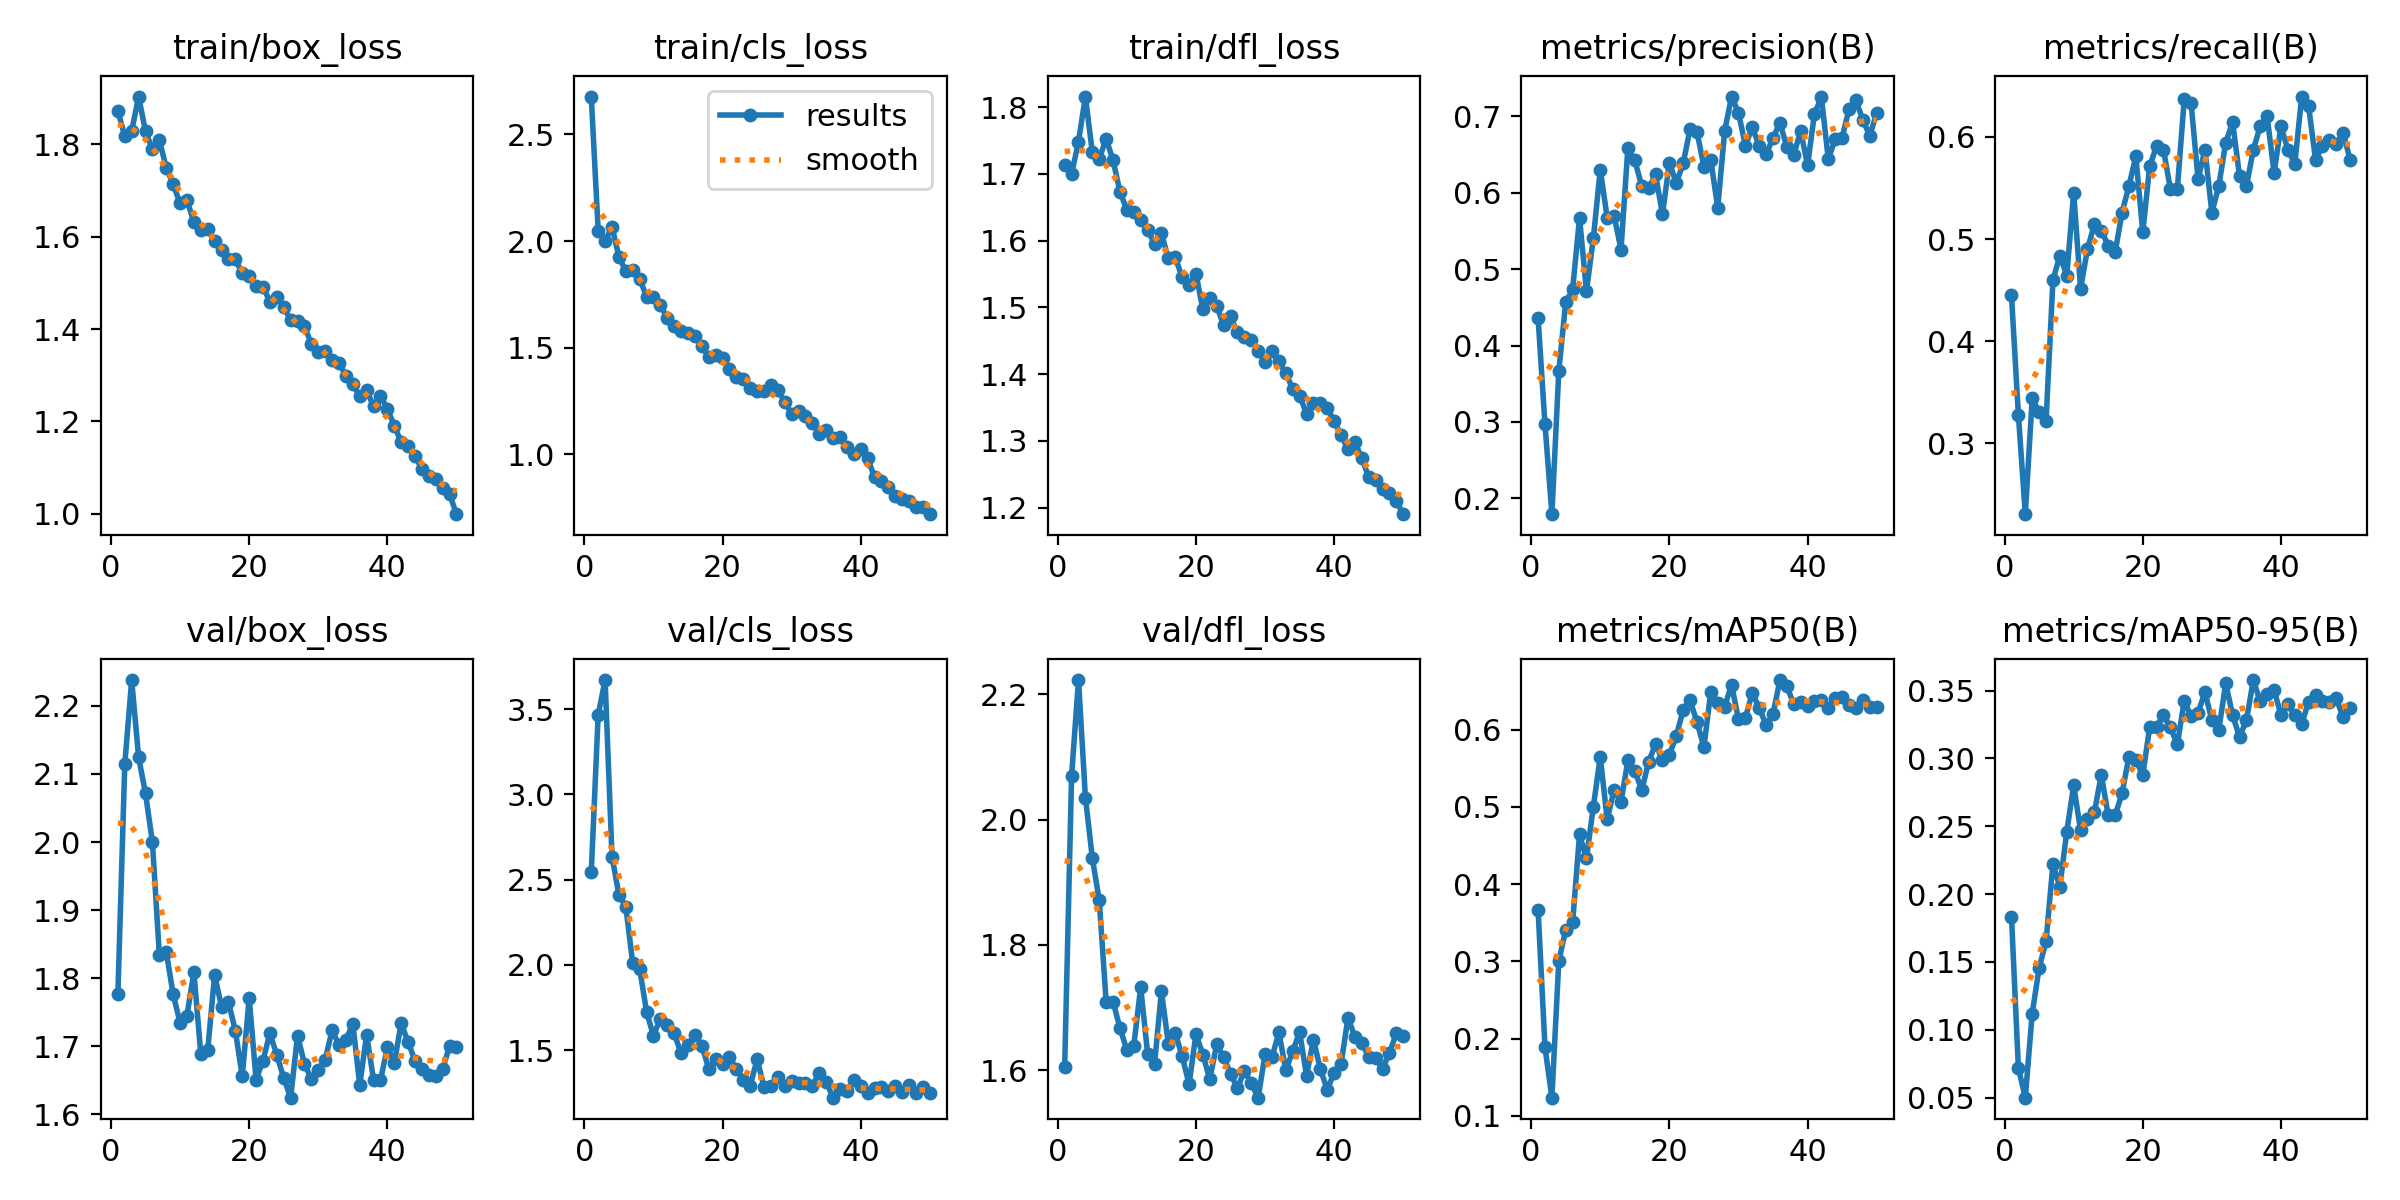

In [ ]:
# DISPLAY TRAINING RESULTS GRAPH

from IPython.display import Image

Image("/content/runs/detect/Pothole_Detection_Project/Pothole_Model/results.png")

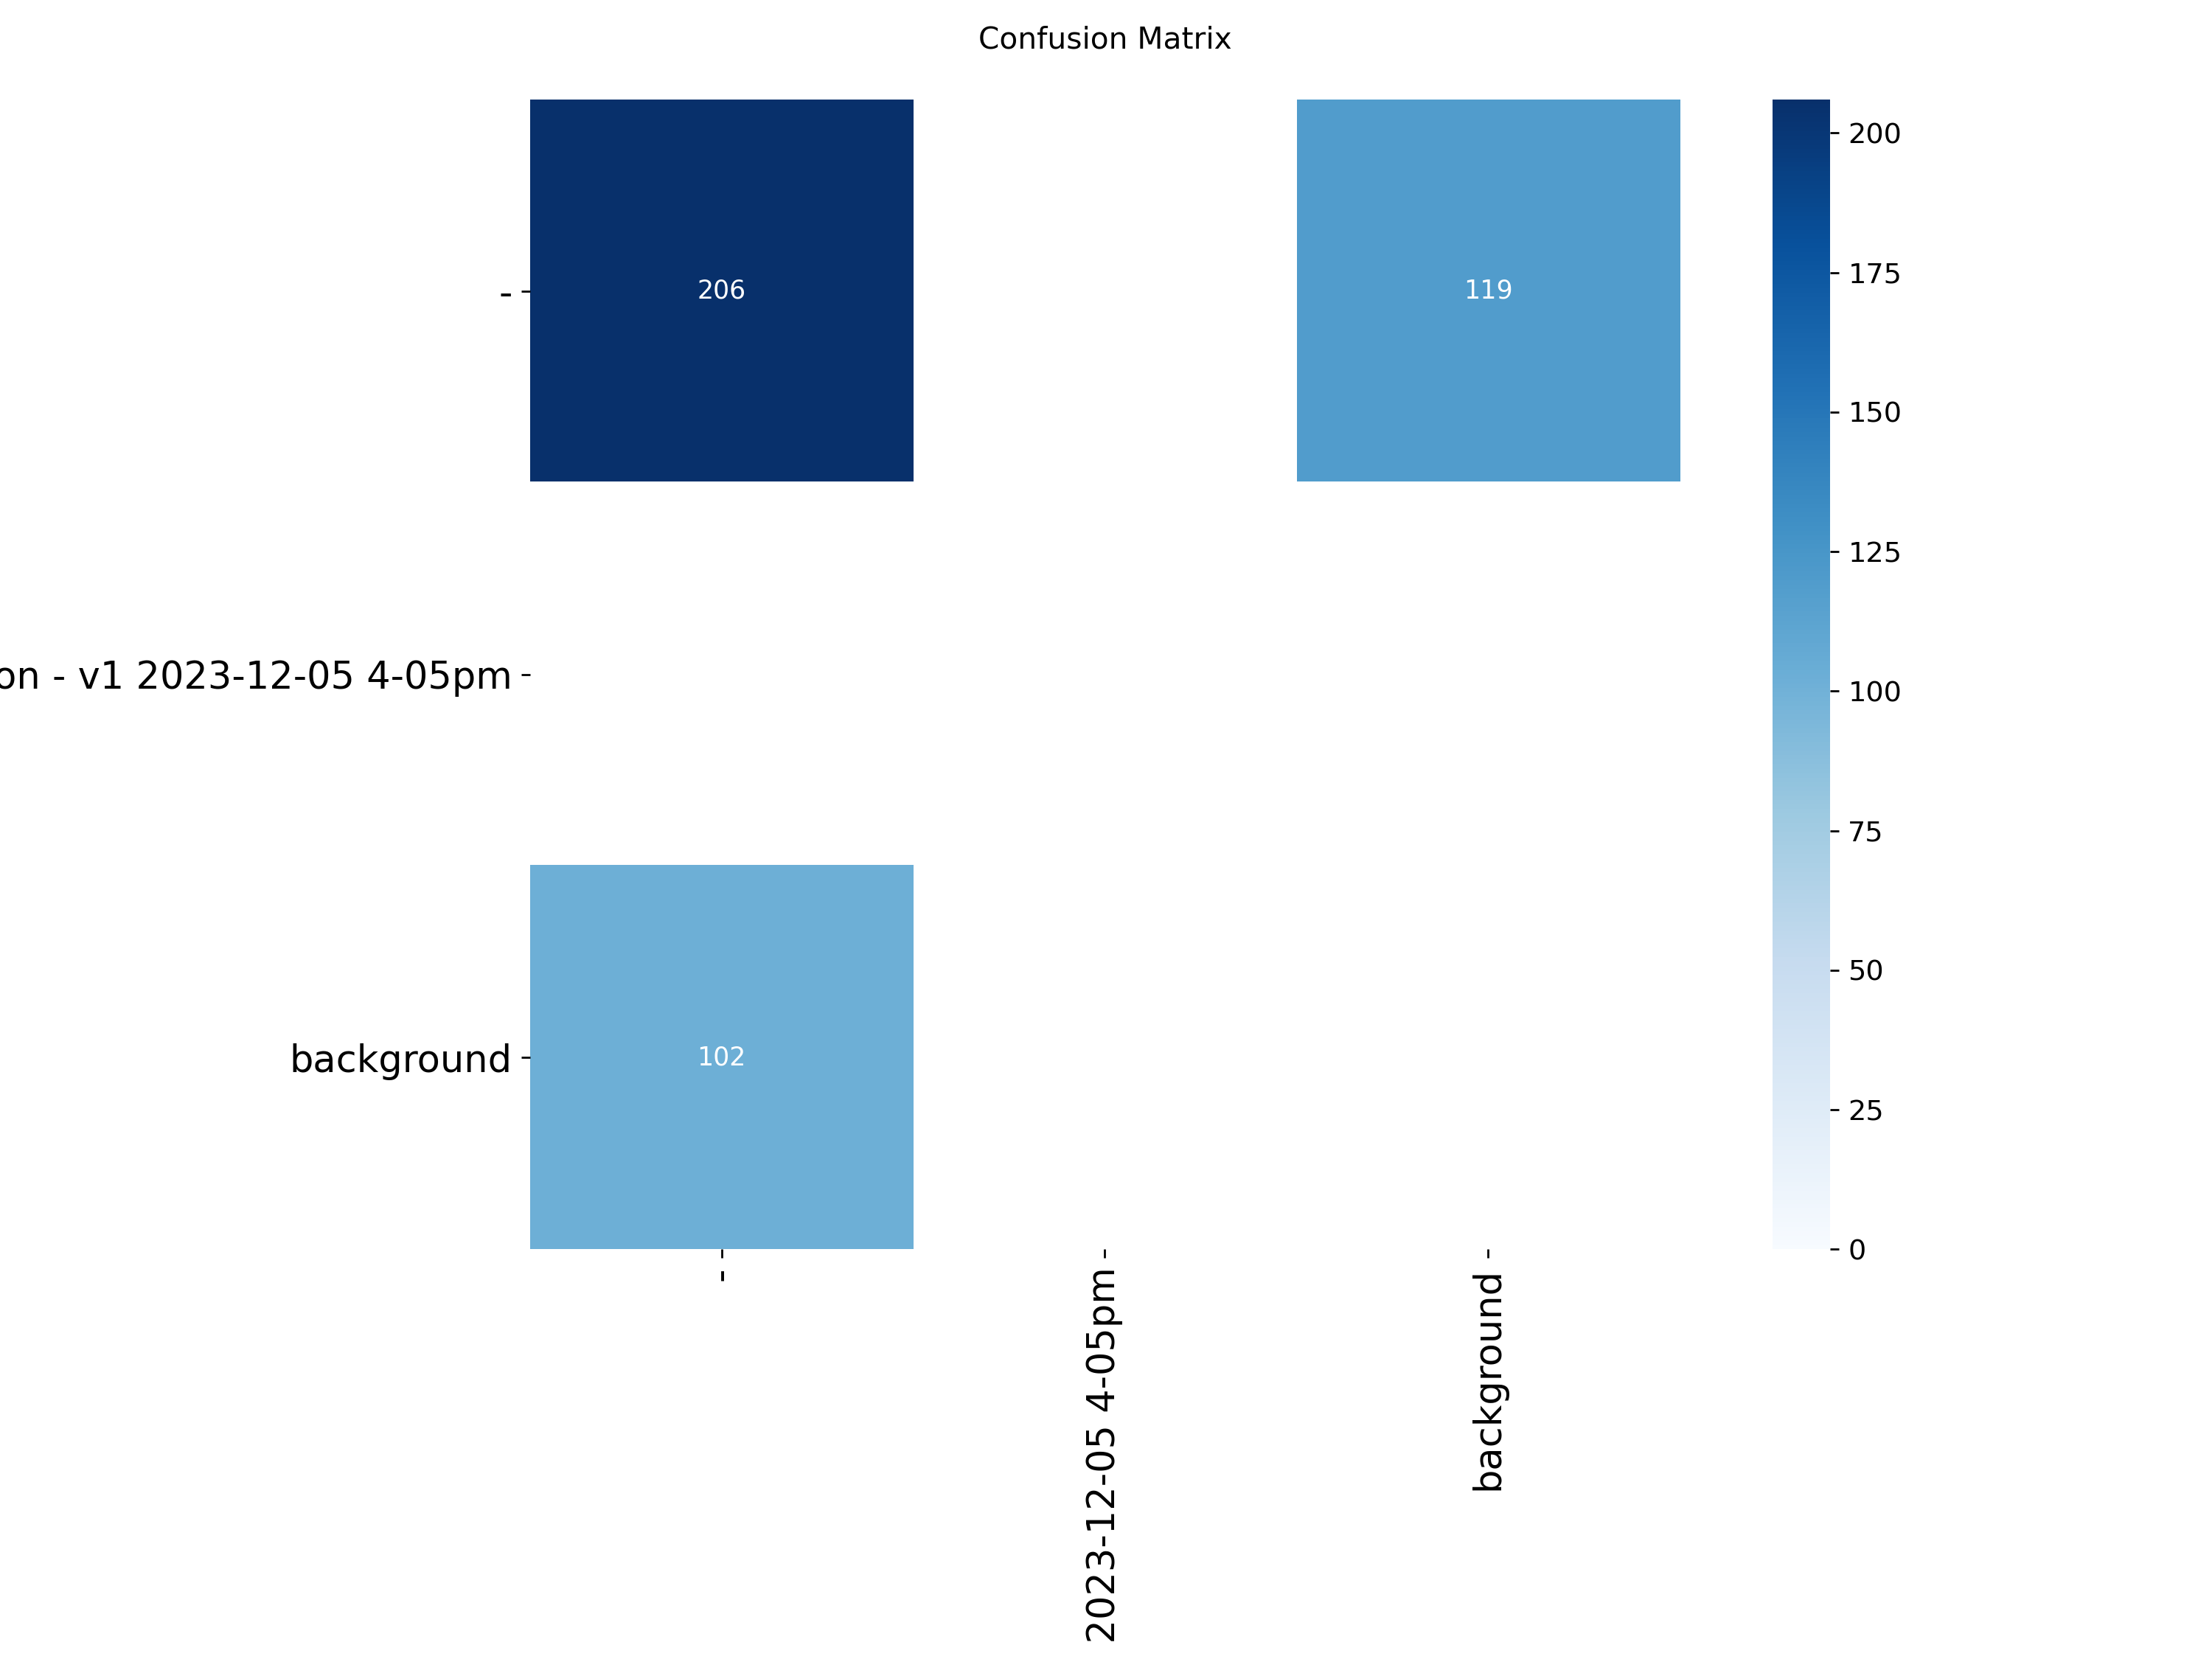

In [ ]:
# DISPLAY CONFUSION MATRIX

from IPython.display import Image

Image("/content/runs/detect/Pothole_Detection_Project/Pothole_Model/confusion_matrix.png")

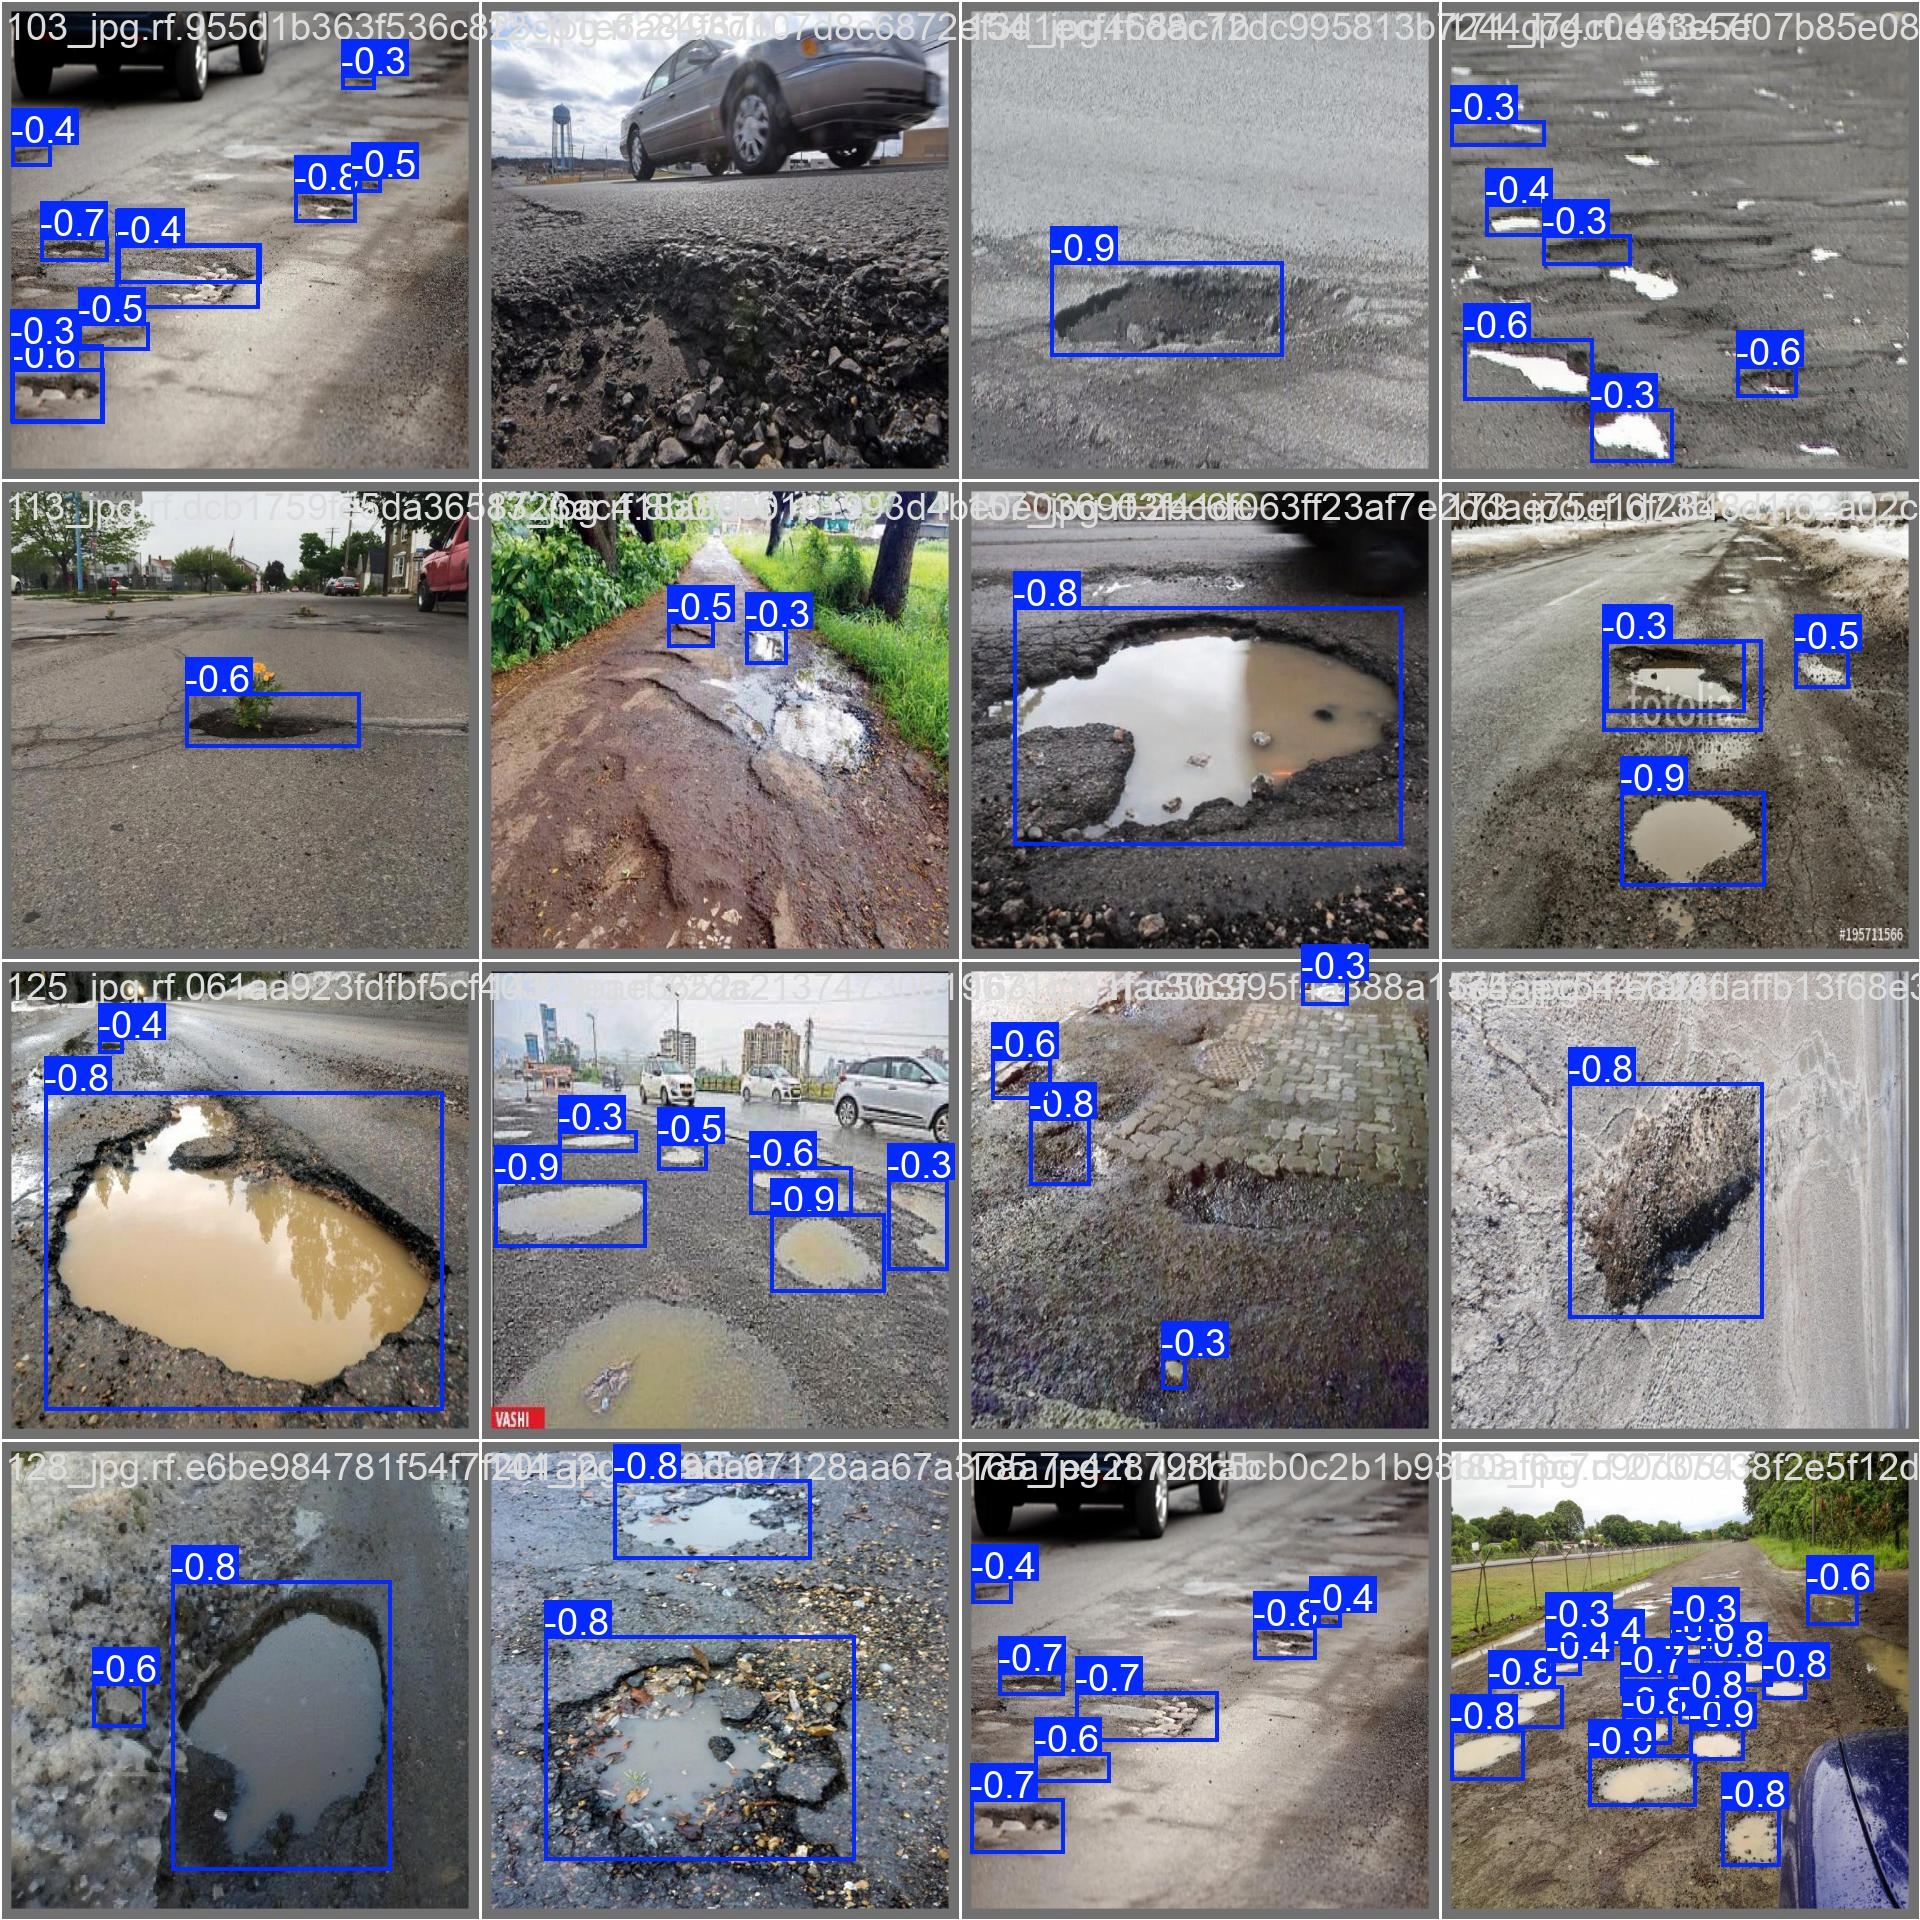

In [ ]:
# DISPLAY SAMPLE PREDICTIONS

from IPython.display import Image

Image("/content/runs/detect/Pothole_Detection_Project/Pothole_Model/val_batch0_pred.jpg")

In [ ]:
# DOWNLOAD BEST MODEL

from google.colab import files

files.download(
    "/content/runs/detect/Pothole_Detection_Project/Pothole_Model/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# POTHOLE DETECTION TEST FUNCTION
# ==========================================

from ultralytics import YOLO
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

model = YOLO(
    "/content/runs/detect/Pothole_Detection_Project/Pothole_Model/weights/best.pt"
)

def test_pothole_detection(image_path=None):

    if image_path is None:
        uploaded = files.upload()
        image_path = list(uploaded.keys())[0]

    results = model.predict(
        source=image_path,
        conf=0.25
    )

    annotated_img = results[0].plot()

    plt.figure(figsize=(8,8))
    plt.imshow(annotated_img)
    plt.axis("off")
    plt.show()


image 1/1 /content/Pathole-Detection-1/test/images/102_jpg.rf.45648573178bfe79169c23adc23afd86.jpg: 640x640 2 -s, 16.2ms
Speed: 2.4ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


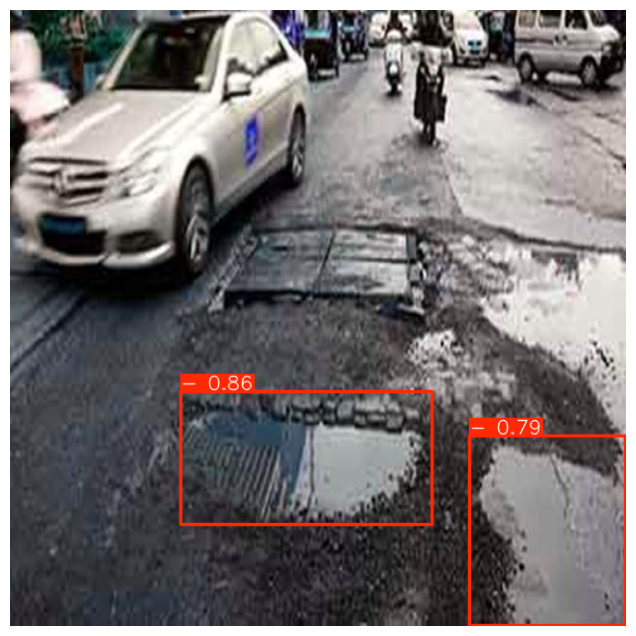

In [ ]:
# TEST WITH SAMPLE IMAGE

test_pothole_detection(
    "/content/Pathole-Detection-1/test/images/102_jpg.rf.45648573178bfe79169c23adc23afd86.jpg"
)

Saving pothole.jpg to pothole.jpg

image 1/1 /content/pothole.jpg: 384x640 8 -s, 50.9ms
Speed: 3.1ms preprocess, 50.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


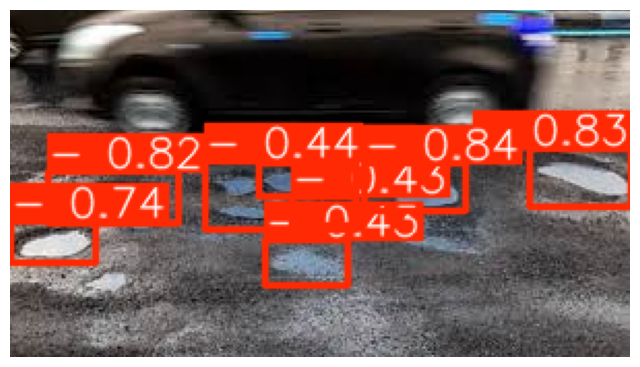

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

Saving images.jpg to images.jpg

image 1/1 /content/images.jpg: 448x640 1 -, 53.7ms
Speed: 3.0ms preprocess, 53.7ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


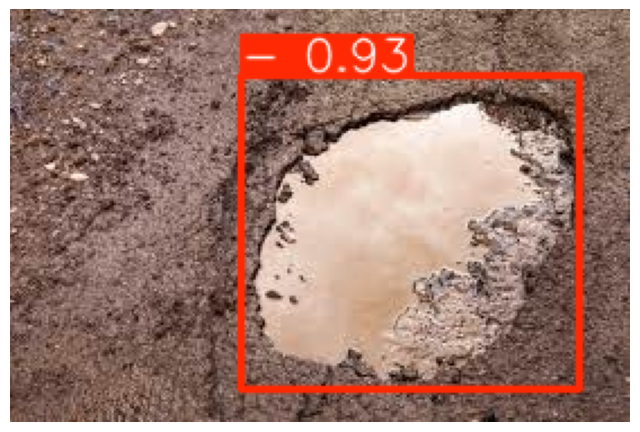

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

Saving images (1).jpg to images (1).jpg

image 1/1 /content/images (1).jpg: 320x640 1 -, 48.5ms
Speed: 2.2ms preprocess, 48.5ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)


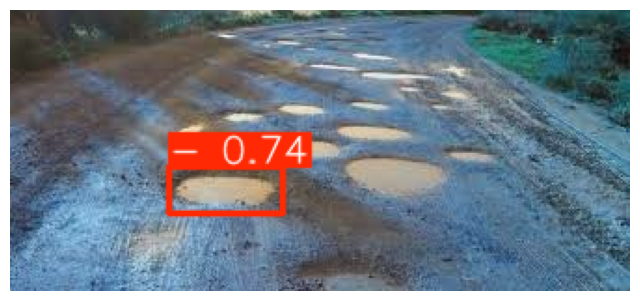

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

Saving images (2).jpg to images (2).jpg

image 1/1 /content/images (2).jpg: 384x640 1 -, 12.0ms
Speed: 2.4ms preprocess, 12.0ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


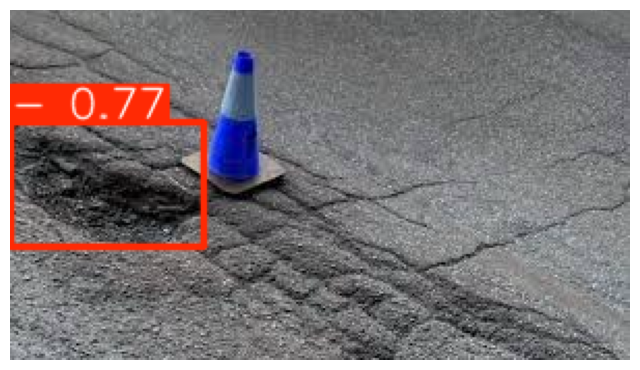

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

Saving images (4).jpg to images (4).jpg

image 1/1 /content/images (4).jpg: 384x640 (no detections), 19.7ms
Speed: 2.9ms preprocess, 19.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


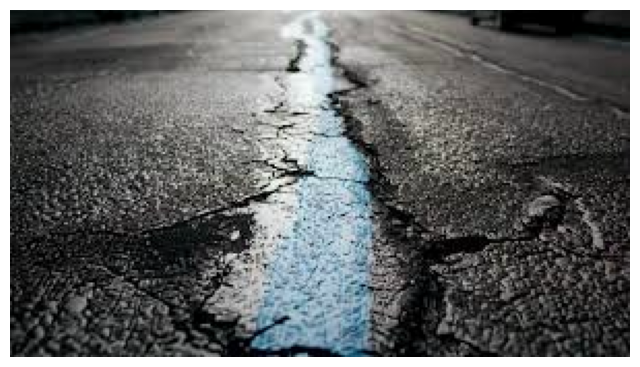

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

Saving images (5).jpg to images (5).jpg

image 1/1 /content/images (5).jpg: 544x640 1 -, 49.7ms
Speed: 2.6ms preprocess, 49.7ms inference, 1.4ms postprocess per image at shape (1, 3, 544, 640)


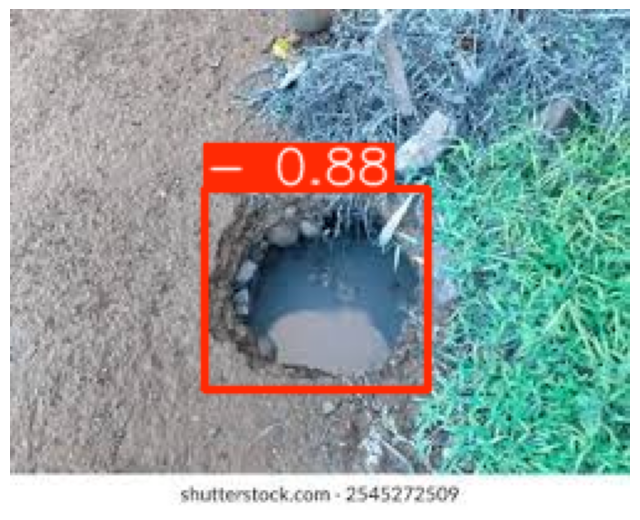

In [ ]:
# TEST WITH YOUR OWN IMAGE

test_pothole_detection()

In [ ]:
!zip -r runs.zip /content/runs

updating: content/runs/ (stored 0%)
updating: content/runs/detect/ (stored 0%)
updating: content/runs/detect/Pothole_Detection_Project/ (stored 0%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/ (stored 0%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/confusion_matrix.png (deflated 33%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/val_batch0_pred.jpg (deflated 5%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/val_batch1_labels.jpg (deflated 5%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/train_batch0.jpg (deflated 1%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/val_batch2_pred.jpg (deflated 8%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/BoxPR_curve.png (deflated 19%)
updating: content/runs/detect/Pothole_Detection_Project/Pothole_Model/confusion_matrix_normalized.png (deflated 34%)
updating: content/runs/detect/

In [ ]:
from google.colab import files
files.download('/content/runs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>